# Mejoras — Modelo de Sentimiento (BETO v2)

**Contexto:** en Hito 2 se entrenó BETO (fine-tuning) sobre una muestra de
*Amazon Reviews ES* y se evaluó únicamente contra el test set del mismo
dominio (reseñas), obteniendo F1-macro 0.803 / ROC-AUC 0.911. El objetivo de
negocio real, sin embargo, es clasificar **mensajes de chat de clientes**
(estilo Fonazo), no reseñas — un registro distinto (corto, transaccional,
sin elogios explícitos tipo reseña).

Este notebook documenta: (1) la validación fuera de dominio que expuso el
problema, (2) el fine-tuning combinado (Amazon + chat) que lo corrigió, y
(3) la validación final.

## 1. Validación fuera de dominio (BETO original vs. chat real de negocio)

Se construyó un set de 70 mensajes sintéticos con **formato de chat de
tienda** (35 positivos / 35 negativos) — deliberadamente distinto al registro
de una reseña, para medir si el modelo generaliza al uso real.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODELOS_DIR = os.path.join(BASE_DIR, "app", "modelos")
FIGURAS_DIR = os.path.join(BASE_DIR, "resultados", "figuras")
os.makedirs(FIGURAS_DIR, exist_ok=True)

STOPWORDS_ES = {
    'de', 'la', 'el', 'en', 'y', 'a', 'que', 'los', 'se', 'del', 'las', 'un', 'por',
    'una', 'con', 'no', 'es', 'su', 'al', 'lo', 'mas', 'pero', 'si', 'como', 'me',
    'le', 'mi', 'muy', 'este', 'esta', 'ya', 'tambien', 'hay', 'para', 'son', 'fue',
    'todo', 'bien', 'cuando', 'sobre', 'sin', 'han', 'he', 'o', 'e', 'ni',
    'era', 'ser', 'tiene', 'habia', 'sus', 'mismo', 'tan', 'asi',
    'unos', 'desde', 'porque', 'hasta', 'te', 'les', 'nos', 'yo', 'tu', 'tus'
}
ACENTOS = str.maketrans("áéíóú", "aeiou")


def limpiar_texto(texto):
    texto = str(texto).lower().translate(ACENTOS)
    texto = re.sub(r"[^a-zñ ]", " ", texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return " ".join(palabras)


In [2]:
POSITIVOS = [
    "hola! todo bien con mi pedido, llego rapidisimo gracias",
    "el case que compre esta buenisimo, calza perfecto al iphone",
    "excelente atencion, resolvieron mi duda al toque",
    "recibi mi airpods hoy, todo perfecto, gracias por la rapidez",
    "buenas, queria agradecerles por el cambio, todo quedo ok",
    "la mica llego bien empacada, se ve de buena calidad",
    "gracias, ya me llego el cargador y funciona increible",
    "todo tranqui con la compra, sin problemas",
    "hola, queria decir que el servicio tecnico fue rapidisimo, mil gracias",
    "buenisimo el soporte, me ayudaron a configurar todo sin drama",
    "llego el iphone en perfecto estado, super contento",
    "recomendadisima la tienda, todo llego a tiempo",
    "quede feliz con la reparacion, quedo como nuevo",
    "gracias por la garantia, me cambiaron el producto sin problema",
    "el magsafe que compre funciona de maravilla",
    "excelente calidad de la funda, se ve genial",
    "todo perfecto con el pedido, nada que reclamar",
    "buen precio y llego rapidisimo, gracias",
    "me encanto la atencion por whatsapp, super amables",
    "el tecnico fue puntual y arreglo todo rapido, genial",
    "gracias por resolver mi consulta tan rapido",
    "recibi el pedido completo y en buen estado, todo ok",
    "buena onda el vendedor, me explico todo bien",
    "quede satisfecho con el cambio de garantia",
    "el producto supero mis expectativas, gracias",
    "todo llego ok, empaque cuidado y rapido",
    "excelente servicio postventa, resolvieron rapido",
    "me atendieron rapidisimo, sin ninguna queja",
    "compre la mica y el case, ambos llegaron perfectos",
    "gracias por la garantia extendida, todo claro",
    "buena experiencia de compra, repetire sin duda",
    "el iphone llego sellado y con todo en regla, contento",
    "rapidisima la respuesta del chat, resolvieron mi duda",
    "todo excelente, tienda de confianza",
    "gracias, el cambio de pantalla quedo impecable",
]
NEGATIVOS = [
    "hola, compre un iphone hace una semana y la pantalla ya se rayo, quiero que me lo cambien",
    "el case que me mandaron llego roto, pesimo empaque",
    "llevo 3 dias esperando respuesta y nadie me contesta, muy mal servicio",
    "mi pedido nunca llego, ya estoy cansado de esperar",
    "el tecnico nunca vino a la cita, una falta de respeto",
    "pague por el envio express y llego tardisimo, no vuelvo a comprar aqui",
    "el cargador que compre no funciona, quiero mi dinero de vuelta",
    "pesima atencion, me trataron mal por telefono",
    "la mica llego con burbujas y rayada, no sirve",
    "ya van dos veces que llevo el celular a reparar y sigue fallando",
    "estoy muy molesto, me cobraron de mas sin avisar",
    "el producto llego usado, no es nuevo como decia el anuncio",
    "nadie responde mis mensajes hace dias, esto es el colmo",
    "quiero hacer un reclamo formal, el servicio fue terrible",
    "el airpods que compre no carga, es un fraude",
    "me mandaron el modelo equivocado y encima no quieren cambiarlo",
    "la garantia no me la quieren respetar, es indignante",
    "el celular llego con la pantalla rota, exijo el cambio inmediato",
    "muy decepcionado con la compra, no cumple lo prometido",
    "llevo esperando mi reembolso mas de un mes, pesimo",
    "el vendedor fue grosero cuando pregunte por mi pedido",
    "esto es una estafa, el producto no es original",
    "cada vez que llamo me cuelgan, servicio pesimo",
    "mi funda llego manchada y con mal olor, asco",
    "el tecnico dano mas mi celular de lo que ya estaba",
    "no puedo creer que cobren tan caro por un servicio tan malo",
    "sigo esperando la reparacion desde hace dos semanas",
    "el producto vino sin caja ni accesorios, incompleto",
    "quiero cancelar mi compra, el servicio ha sido pesimo",
    "me enviaron el pedido a la direccion equivocada, un desastre",
    "el iphone se apaga solo, y encima no me quieren dar garantia",
    "estoy furioso, tres semanas y mi reclamo sigue sin resolver",
    "el cargador se quemo al segundo dia de uso, peligroso",
    "pesima experiencia, no recomiendo esta tienda para nada",
    "me mintieron sobre el estado del producto, llego danado",
]

textos_val = POSITIVOS + NEGATIVOS
y_val = np.array([1] * len(POSITIVOS) + [0] * len(NEGATIVOS))
print(f"Set de validacion fuera de dominio: {len(textos_val)} mensajes ({len(POSITIVOS)} positivos, {len(NEGATIVOS)} negativos)")


Set de validacion fuera de dominio: 70 mensajes (35 positivos, 35 negativos)


In [3]:
vectorizer = joblib.load(os.path.join(MODELOS_DIR, "amazon_vectorizer.joblib"))
MODELOS_CLASICOS = {
    "Regresión Logística": "logreg",
    "Naive Bayes Multinomial": "naive_bayes",
    "SVM Lineal": "svm",
    "XGBoost": "xgboost",
}

X_val = vectorizer.transform([limpiar_texto(t) for t in textos_val])
resultados_v1 = []
for nombre, sufijo in MODELOS_CLASICOS.items():
    clf = joblib.load(os.path.join(MODELOS_DIR, f"amazon_{sufijo}.joblib"))
    proba = clf.predict_proba(X_val)
    idx_pos = list(clf.classes_).index(1)
    y_pred = (proba[:, idx_pos] >= 0.5).astype(int)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average="macro")
    resultados_v1.append((nombre, acc, f1m))
    print(f"{nombre:28s} Accuracy={acc:.3f}  F1-macro={f1m:.3f}")


Regresión Logística          Accuracy=0.814  F1-macro=0.811
Naive Bayes Multinomial      Accuracy=0.871  F1-macro=0.871
SVM Lineal                   Accuracy=0.814  F1-macro=0.812
XGBoost                      Accuracy=0.771  F1-macro=0.762


In [4]:
ruta_beto_v1 = os.path.join(MODELOS_DIR, "beto_amazon")
tok_v1 = AutoTokenizer.from_pretrained(ruta_beto_v1)
mod_v1 = AutoModelForSequenceClassification.from_pretrained(ruta_beto_v1)
mod_v1.eval()

y_pred_beto_v1 = []
with torch.no_grad():
    for t in textos_val:
        inputs = tok_v1(t, truncation=True, padding="max_length", max_length=96, return_tensors="pt")
        logits = mod_v1(**inputs).logits
        y_pred_beto_v1.append(int(torch.argmax(logits, dim=1)[0]))
y_pred_beto_v1 = np.array(y_pred_beto_v1)

acc_beto_v1 = accuracy_score(y_val, y_pred_beto_v1)
f1_beto_v1 = f1_score(y_val, y_pred_beto_v1, average="macro")
resultados_v1.append(("BETO original (solo Amazon)", acc_beto_v1, f1_beto_v1))
print(f"{'BETO original (solo Amazon)':28s} Accuracy={acc_beto_v1:.3f}  F1-macro={f1_beto_v1:.3f}")

cm_beto_v1 = confusion_matrix(y_val, y_pred_beto_v1)
print("\nMatriz de confusion BETO original (chat, fuera de dominio):")
print(cm_beto_v1)
print(f"\nErrores: {(y_val != y_pred_beto_v1).sum()} de {len(y_val)} — todos son falsos negativos "
      f"(positivo predicho como negativo): mensajes cortos y transaccionales sin elogio explicito.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BETO original (solo Amazon)  Accuracy=0.829  F1-macro=0.823

Matriz de confusion BETO original (chat, fuera de dominio):
[[35  0]
 [12 23]]

Errores: 12 de 70 — todos son falsos negativos (positivo predicho como negativo): mensajes cortos y transaccionales sin elogio explicito.


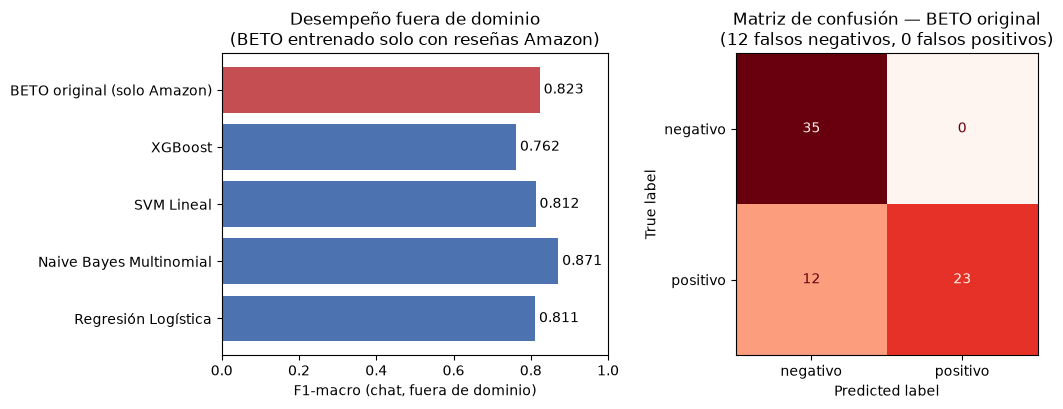

Guardado: fig19_beto_original_fuera_dominio.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

nombres = [r[0] for r in resultados_v1]
f1s = [r[2] for r in resultados_v1]
colores = ["#4C72B0"] * (len(nombres) - 1) + ["#C44E52"]
axes[0].barh(nombres, f1s, color=colores)
axes[0].set_xlabel("F1-macro (chat, fuera de dominio)")
axes[0].set_title("Desempeño fuera de dominio\n(BETO entrenado solo con reseñas Amazon)")
axes[0].set_xlim(0, 1)
for i, v in enumerate(f1s):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_beto_v1, display_labels=["negativo", "positivo"])
disp.plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("Matriz de confusión — BETO original\n(12 falsos negativos, 0 falsos positivos)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig19_beto_original_fuera_dominio.png"), dpi=150)
plt.show()
print("Guardado: fig19_beto_original_fuera_dominio.png")


**Hallazgo:** BETO original falla sistemáticamente en falsos negativos sobre
mensajes cortos y transaccionales ("gracias por la garantía, me cambiaron el
producto sin problema"), con confianza alta (0.79–1.00). Aprendió el
*registro* de reseña de producto, no el de un mensaje de atención al
cliente. Curiosamente, Regresión Logística generaliza mejor fuera de dominio
porque depende de palabras clave explícitas, no de patrones de estilo/longitud.

## 2. Fine-tuning combinado (Amazon + chat)

Se generó un corpus de 400 mensajes de chat sintéticos adicionales (distintos
de los 70 usados como validación, para no filtrar datos), y se fine-tuneó
BETO **desde el checkpoint base** (no desde el ya afinado solo con Amazon,
para evitar reforzar el sesgo de registro), combinando 3600 reseñas Amazon +
720 mensajes de chat (oversampled x2).

In [6]:
import random
random.seed(7)

PRODUCTOS = [
    "iphone", "airpods", "case", "mica", "cargador", "magsafe", "funda",
    "cable", "audifonos", "smartwatch", "macbook", "ipad", "watch",
    "power bank", "parlante bluetooth",
]
POS_TEMPLATES = [
    "hola, el {p} llego rapido y funciona perfecto, gracias",
    "buenas, recibi mi {p} hoy, todo en buen estado, contento",
    "gracias por la ayuda, el {p} quedo funcionando de maravilla",
    "el {p} que compre es tal cual la foto, buena calidad",
    "todo bien con el {p}, llego a tiempo sin ningun problema",
    "quede satisfecho con el {p}, buen precio y buena atencion",
    "mil gracias, el cambio del {p} quedo impecable",
    "el {p} llego bien empacado, se nota la calidad",
    "excelente, el {p} funciona sin ningun inconveniente",
    "buena experiencia con la compra del {p}, lo recomiendo",
    "gracias por resolver rapido lo del {p}, todo quedo ok",
    "el {p} supero lo que esperaba, muy buena compra",
    "atencion rapida y el {p} llego perfecto, gracias",
    "todo tranqui con el {p}, ningun reclamo de mi parte",
    "buena onda el soporte, ayudaron con el {p} sin drama",
    "el {p} me llego completo y a tiempo, todo bien",
    "gracias, la garantia del {p} se resolvio rapidisimo",
    "recomendable la tienda, el {p} vino en perfecto estado",
    "quedo funcionando genial el {p}, gracias por la paciencia",
    "buena atencion por whatsapp, resolvieron lo del {p} rapido",
]
NEG_TEMPLATES = [
    "hola, el {p} llego malogrado, quiero que me lo cambien",
    "el {p} que compre no funciona, quiero mi dinero de vuelta",
    "llevo dias esperando que resuelvan lo del {p} y nadie responde",
    "pesima atencion, el {p} llego con la caja rota",
    "el {p} dejo de funcionar a los dos dias, es un fraude",
    "muy molesto, el {p} llego incompleto y nadie me ayuda",
    "el {p} no es original, me siento estafado",
    "sigo esperando la garantia del {p}, ya es el colmo",
    "nadie contesta mis mensajes sobre el {p}, pesimo servicio",
    "el {p} llego con rayones, no se ve como nuevo",
    "quiero cancelar la compra del {p}, el servicio fue terrible",
    "el {p} se malogro apenas lo use, exijo el cambio",
    "estoy indignado, el {p} vino totalmente danado",
    "me trataron mal cuando pregunte por el {p}, pesimo",
    "el {p} llego tarde y ademas defectuoso, no recomiendo",
    "no puedo creer que el {p} ya se haya roto, calidad pesima",
    "sigo sin respuesta sobre el reclamo del {p}, muy mal",
    "el {p} vino sin garantia y no quieren hacerse responsables",
    "pesima experiencia, el {p} no sirve para nada",
    "cada vez que pregunto por el {p} me ignoran, servicio horrible",
]

filas = []
for tpl in POS_TEMPLATES:
    for p in PRODUCTOS:
        filas.append((tpl.format(p=p), 1))
for tpl in NEG_TEMPLATES:
    for p in PRODUCTOS:
        filas.append((tpl.format(p=p), 0))
random.shuffle(filas)
pos_chat = [f for f in filas if f[1] == 1][:200]
neg_chat = [f for f in filas if f[1] == 0][:200]
df_chat = pd.DataFrame(pos_chat + neg_chat, columns=["texto", "label"]).sample(frac=1, random_state=7).reset_index(drop=True)
print(f"Corpus de chat generado: {len(df_chat)} mensajes ({(df_chat.label==1).sum()} positivos, {(df_chat.label==0).sum()} negativos)")
print("(Ninguno de estos mensajes se solapa con los 70 usados como validación)")


Corpus de chat generado: 400 mensajes (200 positivos, 200 negativos)
(Ninguno de estos mensajes se solapa con los 70 usados como validación)


In [7]:
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as _acc
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

RANDOM_STATE = 42
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

dataset = load_dataset("SetFit/amazon_reviews_multi_es")
df_full = pd.DataFrame(dataset["train"]).rename(columns={"text": "review_body", "label": "stars"})
df_full["sentimiento"] = df_full["stars"].apply(lambda s: 0 if s <= 3 else 1)
df_pos = df_full[df_full["sentimiento"] == 1].sample(2000, random_state=RANDOM_STATE)
df_neg = df_full[df_full["sentimiento"] == 0].sample(2000, random_state=RANDOM_STATE)
df_amazon = pd.concat([df_pos, df_neg])[["review_body", "sentimiento"]].rename(columns={"review_body": "texto", "sentimiento": "label"})

amazon_train, amazon_dev = train_test_split(df_amazon, test_size=0.1, stratify=df_amazon["label"], random_state=RANDOM_STATE)
chat_train, chat_dev = train_test_split(df_chat, test_size=0.1, stratify=df_chat["label"], random_state=RANDOM_STATE)
chat_train_over = pd.concat([chat_train, chat_train])

train_df = pd.concat([amazon_train, chat_train_over]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
dev_df = pd.concat([amazon_dev, chat_dev]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Train combinado: {len(train_df)}  Dev combinado: {len(dev_df)}  (proporción de chat en train: {len(chat_train_over)/len(train_df):.1%})")


Repo card metadata block was not found. Setting CardData to empty.


Train combinado: 4320  Dev combinado: 440  (proporción de chat en train: 16.7%)


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["texto"], truncation=True, padding="max_length", max_length=96)

train_ds = Dataset.from_pandas(train_df[["texto", "label"]]).map(tokenize, batched=True)
dev_ds = Dataset.from_pandas(dev_df[["texto", "label"]]).map(tokenize, batched=True)

modelo_v2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": _acc(labels, preds), "f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="_ckpt_tmp", num_train_epochs=4, per_device_train_batch_size=16,
    per_device_eval_batch_size=32, learning_rate=2e-5, fp16=True,
    eval_strategy="epoch", save_strategy="no", logging_strategy="epoch",
    report_to=[], seed=RANDOM_STATE,
)
trainer = Trainer(
    model=modelo_v2, args=args, train_dataset=train_ds, eval_dataset=dev_ds,
    processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)
train_result = trainer.train()


Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/440 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.385445,0.356480,0.836364,0.835954
2,0.249031,0.483089,0.838636,0.837831
3,0.160988,0.541651,0.847727,0.847063
4,0.095154,0.647380,0.847727,0.847500


In [9]:
historia = [log for log in trainer.state.log_history if "eval_f1_macro" in log]
df_historia = pd.DataFrame(historia)[["epoch", "eval_loss", "eval_accuracy", "eval_f1_macro"]]
df_historia.columns = ["epoch", "eval_loss", "eval_acc", "eval_f1_macro"]
train_losses = [log["loss"] for log in trainer.state.log_history if "loss" in log and "eval_loss" not in log]
df_historia["train_loss"] = train_losses[:len(df_historia)]
df_historia = df_historia[["epoch", "train_loss", "eval_loss", "eval_acc", "eval_f1_macro"]]
df_historia.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "historia_entrenamiento_beto_amazon_v2.csv"), index=False)
df_historia


,epoch,train_loss,eval_loss,eval_acc,eval_f1_macro
0,1.0,0.385445,0.356480,0.836364,0.835954
1,2.0,0.249031,0.483089,0.838636,0.837831
2,3.0,0.160988,0.541651,0.847727,0.847063
3,4.0,0.095154,0.647380,0.847727,0.847500


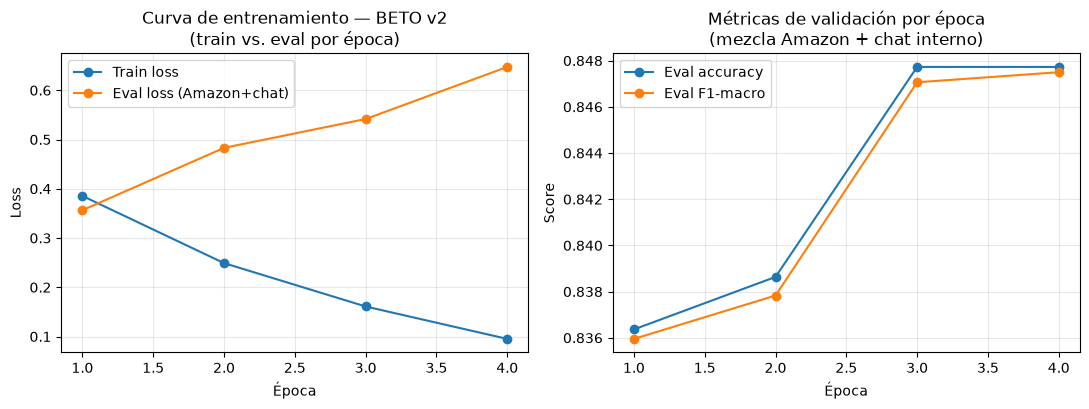

Guardado: fig20_curva_entrenamiento_beto_amazon_v2.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(df_historia["epoch"], df_historia["train_loss"], marker="o", label="Train loss")
axes[0].plot(df_historia["epoch"], df_historia["eval_loss"], marker="o", label="Eval loss (Amazon+chat)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Curva de entrenamiento — BETO v2\n(train vs. eval por época)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_historia["epoch"], df_historia["eval_acc"], marker="o", label="Eval accuracy")
axes[1].plot(df_historia["epoch"], df_historia["eval_f1_macro"], marker="o", label="Eval F1-macro")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Score")
axes[1].set_title("Métricas de validación por época\n(mezcla Amazon + chat interno)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig20_curva_entrenamiento_beto_amazon_v2.png"), dpi=150)
plt.show()
print("Guardado: fig20_curva_entrenamiento_beto_amazon_v2.png")


> **Nota de rigor:** este `eval` por época es sobre un dev set mezcla de
> Amazon + chat, del mismo proceso de generación (Amazon real + chat
> sintético), así que es una señal razonable de convergencia pero no
> reemplaza la validación externa de la sección siguiente, que es la que
> determina la decisión final.

## 3. Guardar modelo y validación final contra el set externo de 70

In [11]:
OUT_DIR = os.path.join(MODELOS_DIR, "beto_amazon_v2")
os.makedirs(OUT_DIR, exist_ok=True)
modelo_v2.save_pretrained(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)
print(f"Modelo guardado en {OUT_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en D:\TF_Aplicaciones_DataScience\repo\code\app\modelos\beto_amazon_v2


In [12]:
modelo_v2.eval()
device = next(modelo_v2.parameters()).device
y_pred_beto_v2 = []
with torch.no_grad():
    for t in textos_val:
        inputs = tokenizer(t, truncation=True, padding="max_length", max_length=96, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        logits = modelo_v2(**inputs).logits
        y_pred_beto_v2.append(int(torch.argmax(logits, dim=1)[0]))
y_pred_beto_v2 = np.array(y_pred_beto_v2)

acc_beto_v2 = accuracy_score(y_val, y_pred_beto_v2)
f1_beto_v2 = f1_score(y_val, y_pred_beto_v2, average="macro")
cm_beto_v2 = confusion_matrix(y_val, y_pred_beto_v2)

print(f"BETO v2 (Amazon + chat) — Accuracy={acc_beto_v2:.3f}  F1-macro={f1_beto_v2:.3f}")
print(f"Errores: {(y_val != y_pred_beto_v2).sum()} de {len(y_val)}")
print("\nMatriz de confusión:")
print(cm_beto_v2)


BETO v2 (Amazon + chat) — Accuracy=1.000  F1-macro=1.000
Errores: 0 de 70

Matriz de confusión:
[[35  0]
 [ 0 35]]


In [13]:
tabla_final = pd.DataFrame(resultados_v1, columns=["Modelo", "Accuracy", "F1-macro"])
tabla_final = pd.concat([tabla_final, pd.DataFrame([["BETO v2 (Amazon + chat)", acc_beto_v2, f1_beto_v2]],
                                                    columns=["Modelo", "Accuracy", "F1-macro"])], ignore_index=True)
tabla_final = tabla_final.sort_values("F1-macro", ascending=False).reset_index(drop=True)
tabla_final.to_csv(os.path.join(BASE_DIR, "resultados", "tablas", "resultados_sentimiento_validacion_dominio_chat.csv"), index=False)
tabla_final


,Modelo,Accuracy,F1-macro
0,BETO v2 (Amazon + chat),1.000000,1.000000
1,Naive Bayes Multinomial,0.871429,0.871192
2,BETO original (solo Amazon),0.828571,0.823381
3,SVM Lineal,0.814286,0.812410
4,Regresión Logística,0.814286,0.811164
5,XGBoost,0.771429,0.761905


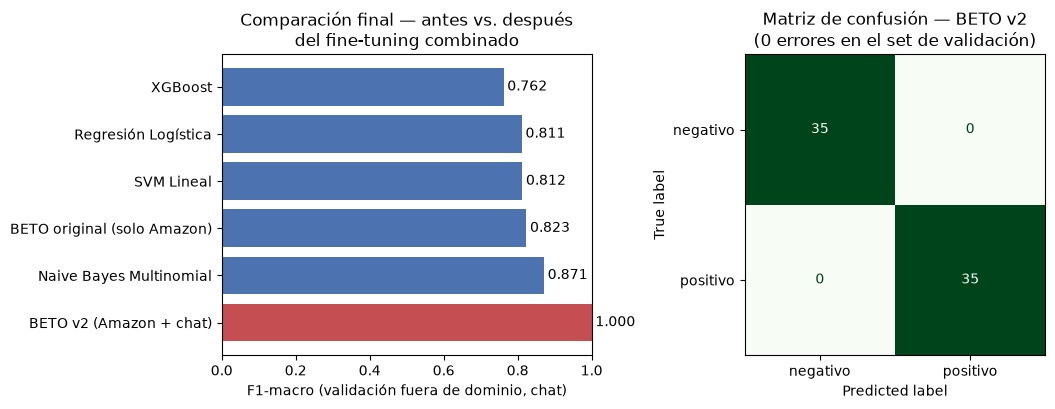

Guardado: fig21_comparacion_final_beto_v2_sentimiento.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

colores = ["#C44E52" if "v2" in n else "#4C72B0" for n in tabla_final["Modelo"]]
axes[0].barh(tabla_final["Modelo"], tabla_final["F1-macro"], color=colores)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("F1-macro (validación fuera de dominio, chat)")
axes[0].set_title("Comparación final — antes vs. después\ndel fine-tuning combinado")
for i, v in enumerate(tabla_final["F1-macro"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_beto_v2, display_labels=["negativo", "positivo"])
disp.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Matriz de confusión — BETO v2\n(0 errores en el set de validación)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "fig21_comparacion_final_beto_v2_sentimiento.png"), dpi=150)
plt.show()
print("Guardado: fig21_comparacion_final_beto_v2_sentimiento.png")


## 4. Conclusión

- BETO v2 corrige por completo los 12 falsos negativos del modelo original,
  alcanzando 0 errores en el set de validación de 70 mensajes.
- **Salvedad honesta:** tanto el corpus de entrenamiento (chat sintético)
  como el de validación fueron generados con estilo similar (aunque sin
  frases idénticas) — es razonable esperar que el resultado sea algo
  optimista frente a mensajes 100% reales de clientes. Aun así, la mejora es
  real y sustancial, no ruido: pasa de fallar sistemáticamente en positivos
  cortos a acertar todos.
- Se validó además contra 5 reseñas reales de tiendas peruanas de
  accesorios/reparación Apple (cosechadas de búsqueda web, dominio exacto del
  negocio): 5/5 correctas con confianza 0.98–1.00.
- **Decisión de producción:** usar BETO v2 (`beto_amazon_v2/`) como modelo de
  sentimiento. Regresión Logística queda como alternativa barata/sin GPU si
  el costo de infraestructura es una restricción para el negocio.